In [1]:
from autoemulate import AutoEmulate
import torch
import pandas as pd
from pathlib import Path

# FOLDER = Path("/home/monroe/libra_pi/libra_sparging/20260422_164947")
FOLDER = Path("training/20260423_123916")

# model = AutoEmulate.load_model(FOLDER / "GaussianProcessRBF_1_20260422_165335.joblib")


In [2]:
X = pd.read_csv(FOLDER / "simulator_inputs.csv")
Y = pd.read_csv(FOLDER / "simulator_outputs.csv")
Z = torch.tensor(Y.values, dtype=torch.float32)

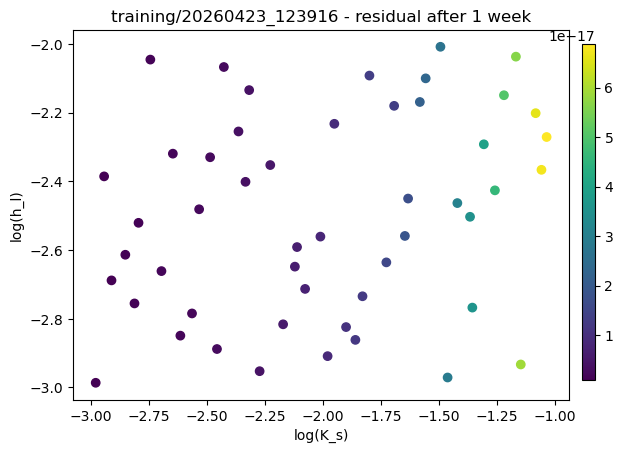

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots()

x_name = "log(K_s)"
y_name = "log(h_l)"
c_name = "log(residual_1week)"
Y_plot = np.power(10, Y[c_name])
# c_name = "residual_1week"
# Y_plot = np.log10(Y[c_name])

plt.sca(axs)
plt.scatter(X[x_name], X[y_name], c=Y_plot, cmap="viridis", vmin=Y_plot.min(), vmax=Y_plot.max())

plt.title(f"{FOLDER} - residual after 1 week")

plt.xlabel(x_name)
plt.ylabel(y_name)

plt.colorbar(cax=fig.add_axes([0.92, 0.15, 0.02, 0.7]))
plt.savefig(FOLDER / "postprocessing" / "scatter.png")
plt.show()

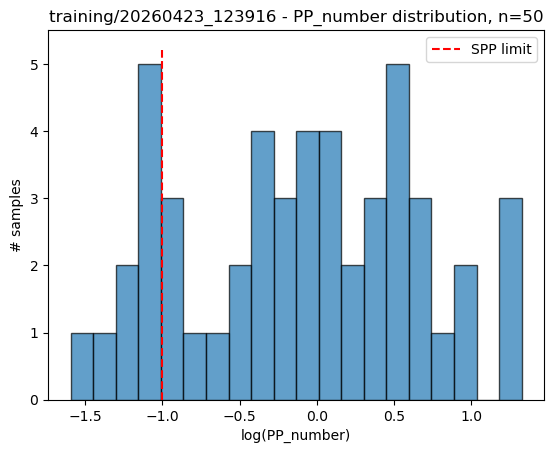

In [4]:
PPs = pd.read_csv(FOLDER / "PP_numbers.csv")

plt.hist(np.log10(PPs.values), bins=20, edgecolor='black', alpha=0.7)
plt.vlines(np.log10(0.1), ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")
plt.title(f"{FOLDER} - PP_number distribution, n={len(PPs)}")
plt.xlabel("log(PP_number)")
plt.ylabel("# samples")
plt.legend()
plt.savefig(FOLDER / "postprocessing" / "PP_distrib.png")

In [5]:
""" PP number range from input parameters range"""

parameters_range={
        "log(h_l)": tuple(np.log10((1e-4, 1e-2))),
        "log(eps_g)": tuple(np.log10((1e-4, 2e-1))),
        "a": (0.05, 0.5),
        "temperature": (450, 800),
        "log(K_s)": tuple(np.log10((1e-3, 1e-0))),
        "u_g0": (0.02, 0.4),
    }
p = parameters_range
PP_max = 8.314 * (np.max(p["temperature"])+273) * 10**np.max(p["log(K_s)"]) * 10**np.max(p["log(h_l)"]) * np.max(p["a"]) * 1 / ((1-10**np.max(p["log(eps_g)"])) * np.min(p["u_g0"]))
PP_min = 8.314 * (np.min(p["temperature"])+273) * 10**np.min(p["log(K_s)"]) * 10**np.min(p["log(h_l)"]) * np.min(p["a"]) * 1 / ((1-10**np.min(p["log(eps_g)"])) * np.max(p["u_g0"]))
print(f"PP range: {PP_min:.2e} - {PP_max:.2e}")

PP range: 7.51e-05 - 2.79e+03


Monte Carlo samples: 5000

PP STATISTICS
  Min:        8.33e-03
  Max:        6.93e+01
  Mean:       2.58e+00
  Std:        5.15e+00
  Median:     8.04e-01
  log10 range: [-2.08, 1.84]


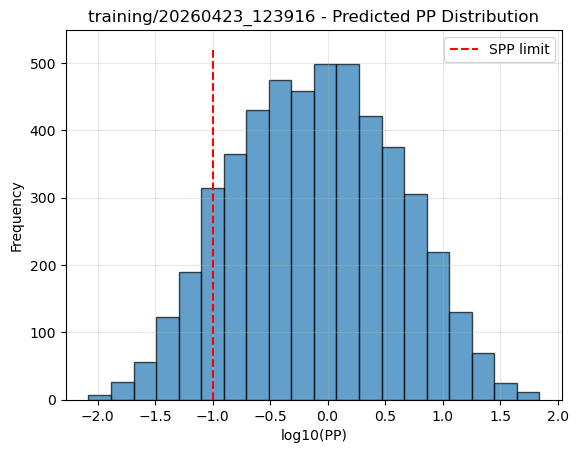

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_pp_sample(parameters_range, n_samples=10000):
    R = 8.314  # Gas constant J/(mol·K)
    
    # Initialize storage for samples
    samples = {key: np.zeros(n_samples) for key in parameters_range.keys()}
    # Sample uniformly from each parameter range
    for param, (min_val, max_val) in parameters_range.items():
        samples[param] = np.random.uniform(min_val, max_val, n_samples)
    
    # Compute PP for each sample
    pp_values = (
        R * 
        (samples["temperature"] + 273) * 
        10**samples["log(K_s)"] * 
        10**samples["log(h_l)"] * 
        samples["a"] / 
        ((1 - 10**samples["log(eps_g)"]) * samples["u_g0"])
    )
    
    return pp_values, samples


parameters_range={
    "log(h_l)": tuple(np.log10((1e-3, 1e-2))),
    "log(eps_g)": tuple(np.log10((1e-4, 2e-1))),
    "a": (0.05, 0.3),
    "temperature": (700, 800),
    "log(K_s)": tuple(np.log10((1e-3, 1e-1))),
    "u_g0": (0.02, 0.1),
}

# Run Monte Carlo
n_samples = 5000
pp_values, samples = monte_carlo_pp_sample(parameters_range, n_samples)

# Statistics
print(f"Monte Carlo samples: {n_samples}")
print(f"\n{'='*50}")
print(f"PP STATISTICS")
print(f"{'='*50}")
print(f"  Min:        {np.min(pp_values):.2e}")
print(f"  Max:        {np.max(pp_values):.2e}")
print(f"  Mean:       {np.mean(pp_values):.2e}")
print(f"  Std:        {np.std(pp_values):.2e}")
print(f"  Median:     {np.median(pp_values):.2e}")
print(f"  log10 range: [{np.log10(np.min(pp_values)):.2f}, {np.log10(np.max(pp_values)):.2f}]")

# Visualization
fig_MC, ax = plt.subplots()

# PP distribution (log scale)
ax.hist(np.log10(pp_values), bins=20,edgecolor='black', alpha=0.7)
# ax.hist(pp_values, bins=50, range=(0,10),edgecolor='black', alpha=0.7)

ax.set_xlabel("log10(PP)")
ax.set_ylabel("Frequency")
ax.set_title(f"{FOLDER} - Predicted PP Distribution")
ax.grid(alpha=0.3)
ax.vlines(np.log10(0.1), ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")
# ax.vlines(0.1, ymin=0, ymax=plt.gca().get_ylim()[1], colors="red", linestyles="dashed", label="SPP limit")

ax.legend()

In [7]:
fig_MC.savefig(FOLDER / "postprocessing" / "pp_monte_carlo.png", dpi=150)

Diagnostic for sample 8: PP=[0.09026422], residual=1.19e-17


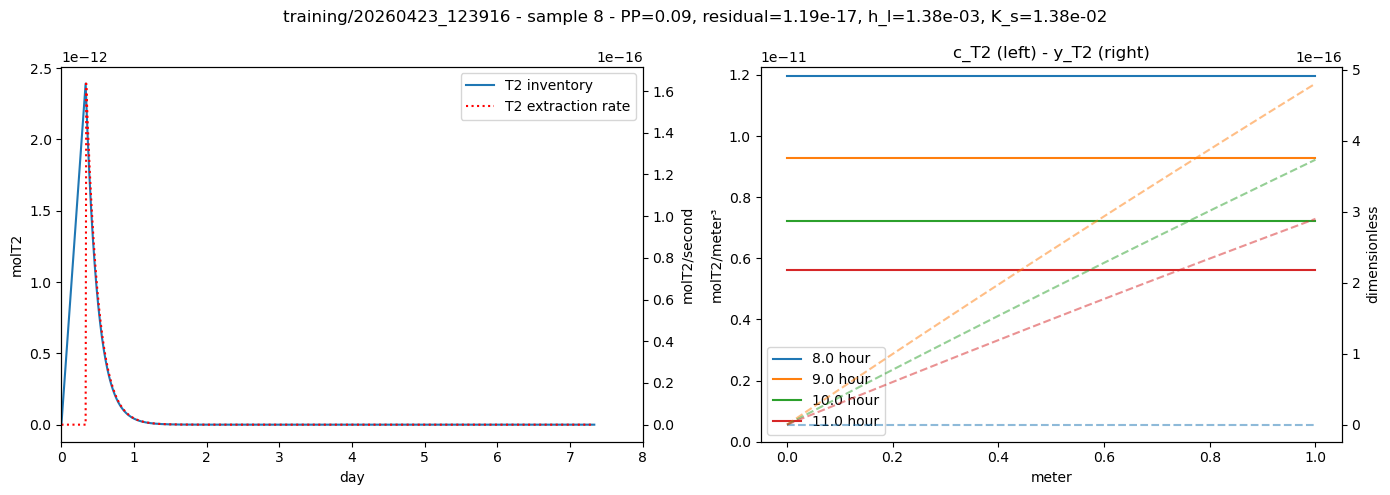

In [29]:
from sparging.model import SimulationResults
from sparging.config import ureg
import sparging.postprocess as pp

idxs = np.argwhere(PPs.values > 1)
# idx = idxs[0,0]
idx = 8
print(f"Diagnostic for sample {idx}: PP={PPs.values[idx]}, residual={10**Y["log(residual_1week)"].values[idx]:.2e}")
sim_result = SimulationResults.from_json(FOLDER/"samples"/f"sample_{idx}.json")

fig, axs = plt.subplots(1,2, figsize=(14,5))
secax0 = axs[0].twinx()
secax1 = axs[1].twinx()
lns1 = axs[0].plot(sim_result.times, sim_result.inventories_T2_salt, label="T2 inventory")
lns2 = secax0.plot(sim_result.times, sim_result.fluxes_T2, color="red", linestyle=":", label="T2 extraction rate")
lns = lns1 + lns2 
labels = [l.get_label() for l in lns]
axs[0].legend(lns, labels)
axs[0].xaxis.set_units(ureg.day)
axs[0].set_xlim(0, 8*ureg.day)

for t in [8, 9, 10, 11]*ureg.hour:
    idx_to_plot = pp.idx_from_t(sim_result.times, t)
    time = sim_result.times[idx_to_plot].to(t.units)
    axs[1].plot(sim_result.x_ct, sim_result.c_T2_solutions[idx_to_plot], label=f"{time:.1f}")
    secax1.plot(sim_result.x_ct, sim_result.y_T2_solutions[idx_to_plot], linestyle="--", alpha=0.5)
axs[1].set_ylim(0)
axs[1].set_title("c_T2 (left) - y_T2 (right)")
axs[1].legend()
fig.suptitle(f"{FOLDER} - sample {idx} - PP={PPs.values[idx,0]:.2f}, residual={10**Y['log(residual_1week)'].values[idx]:.2e}, h_l={10**X['log(h_l)'].values[idx]:.2e}, K_s={10**X['log(K_s)'].values[idx]:.2e}")
fig.tight_layout()

FOLDER_PP = FOLDER / "postprocessing"
FOLDER_PP.mkdir(exist_ok=True)
fig.savefig(FOLDER_PP / f"diagnostic_sample_{idx}.png", dpi=150)

Fitting from t=8.000e+00 h to t=2.400e+01 h (indices 40 to 120)
std:[3.21389940e-06 3.69589746e-22]
Fitted parameters: n0 = 2.39e-12 molT2, tau = 14254.56 second


Text(0.5, 0.98, 'sample 8, tau = 14254.56 second, n0=2.39e-12 molT2')

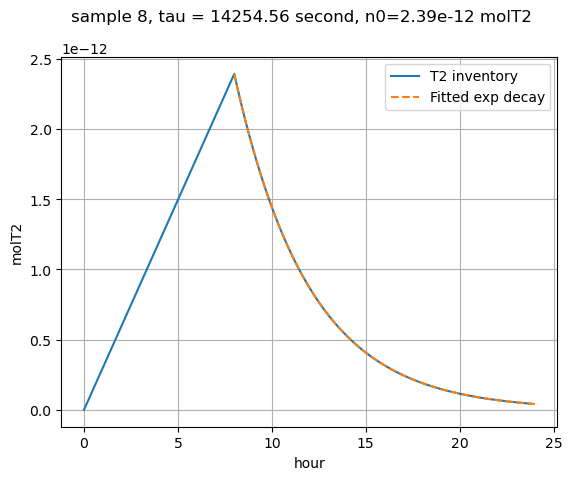

In [30]:
t_0 = 8 * ureg.hour
t_1 = 24 * ureg.hour
t_plot = 24 * ureg.hour
idx_0 = pp.idx_from_t(sim_result.times, t_0)
idx_1 = pp.idx_from_t(sim_result.times, t_1)
idx_plot = pp.idx_from_t(sim_result.times, t_plot)

popt,pcov = pp.fit_exp(sim_result.inventories_T2_salt, sim_result.times, t_0, t_1, phase="decay")
tau, n0 = popt
print(f"Fitted parameters: n0 = {n0:.2e}, tau = {tau.to('s'):.2f}")

# fig, ax = plt.subplots(2,1, figsize=(10,8))
fig,ax = plt.subplots(1,1)
ax.plot(sim_result.times[:idx_plot], sim_result.inventories_T2_salt[:idx_plot], label="T2 inventory")
t_fit = np.linspace(8 * ureg.hour, t_plot, 100)
ax.plot(t_fit, n0 * np.exp(-(t_fit-t_0) / tau), label="Fitted exp decay", linestyle="--")
ax.legend()
ax.xaxis.set_units(ureg.hour)
ax.grid()

fig.suptitle(f"sample {idx}, tau = {tau.to('s'):.2f}, n0={n0:.2e}")
# ax[1].plot(sim_result.times[idx_0:idx_plot+1], sim_result.inventories_T2_salt[idx_0:idx_plot+1] - n0 * np.exp(-(sim_result.times[idx_0:idx_plot+1]-t_0) / tau), label="Error")
# ax[1].xaxis.set_units(ureg.hour)